<a href="https://colab.research.google.com/github/spokenprim618/python100-colabHW/blob/main/CTD_Assignment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
alexteboul_diabetes_health_indicators_dataset_notebook_path = kagglehub.notebook_output_download('alexteboul/diabetes-health-indicators-dataset-notebook')

print('Data source import complete.')


Data source import complete.


In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Task 2

In [6]:
diabetes = pd.read_csv('/root/.cache/kagglehub/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/output/versions/5/diabetes_012_health_indicators_BRFSS2015.csv')

print(diabetes.head())


   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0   
1     

## Task 3

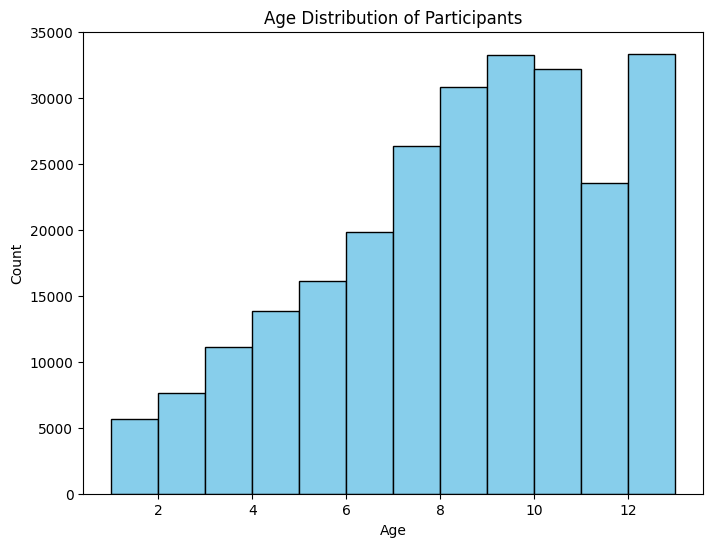

In [7]:
plt.figure(figsize=(8,6))
plt.hist(diabetes['Age'], bins=12, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Participants")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Task 4

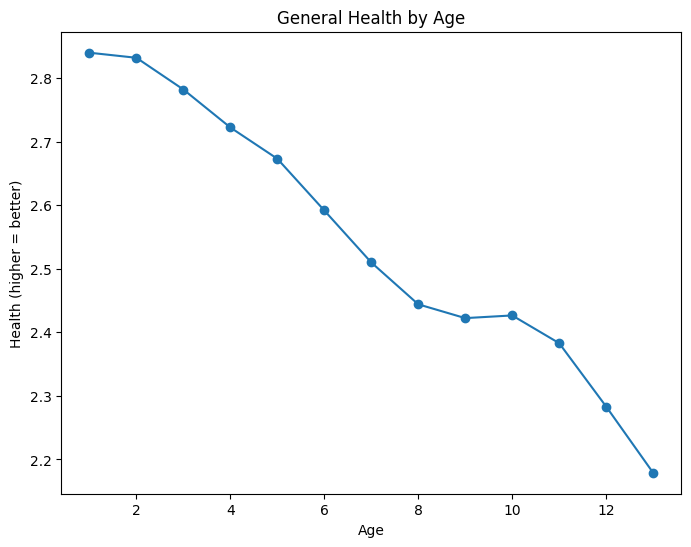

In [8]:
health_by_age = diabetes.groupby('Age')['GenHlth'].mean().to_frame()

health_by_age['Health'] = 5 - health_by_age['GenHlth']

health_by_age = health_by_age.sort_index()

# Plot
plt.figure(figsize=(8,6))
plt.plot(health_by_age.index, health_by_age['Health'], marker='o', linestyle='-')
plt.title("General Health by Age")
plt.xlabel("Age")
plt.ylabel("Health (higher = better)")
plt.show()


## Task 5

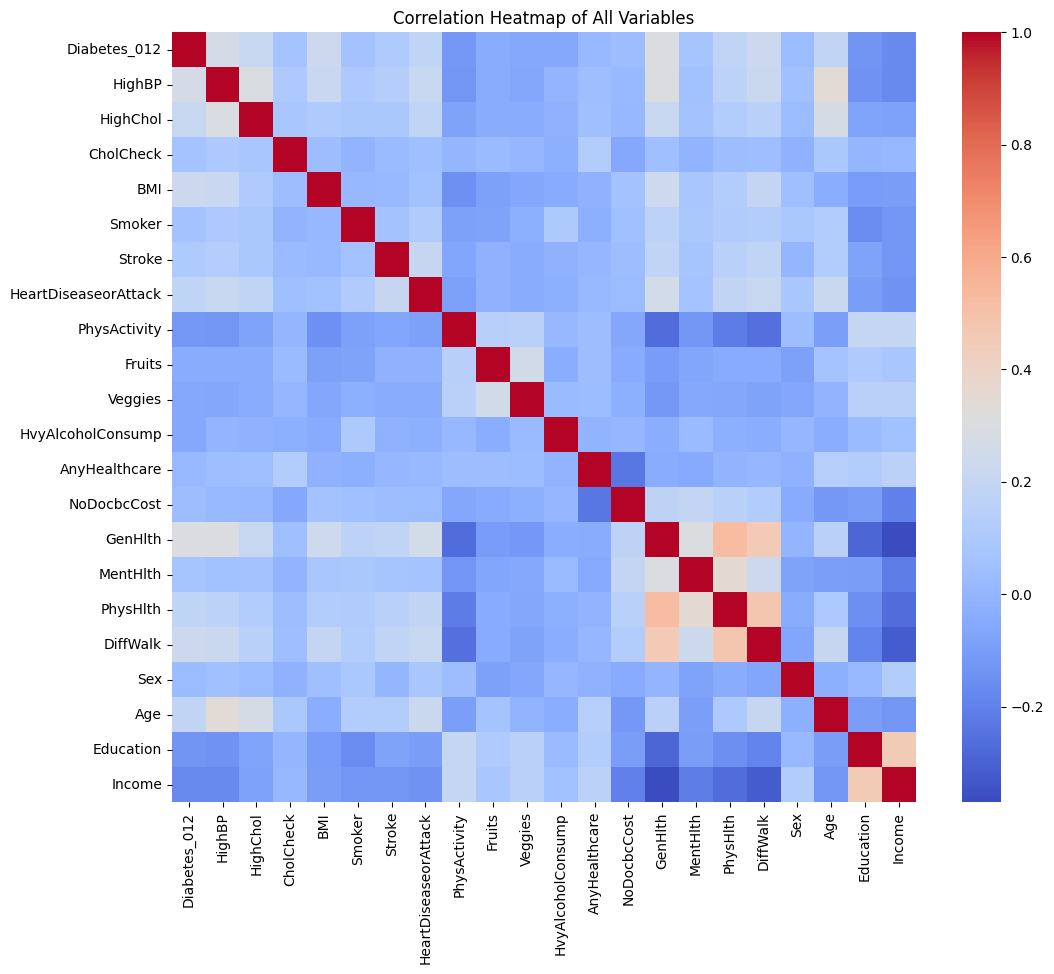

In [9]:
diabetes_corr = diabetes.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(diabetes_corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of All Variables")
plt.show()

## Task 6

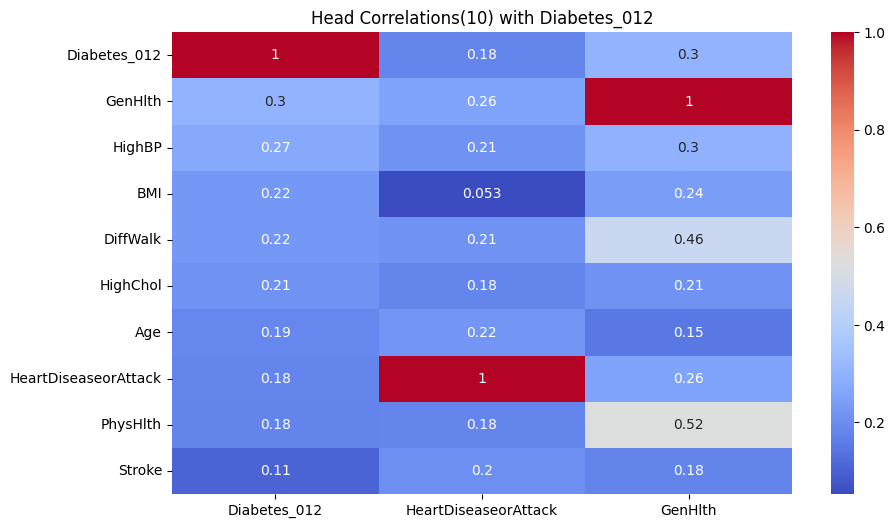

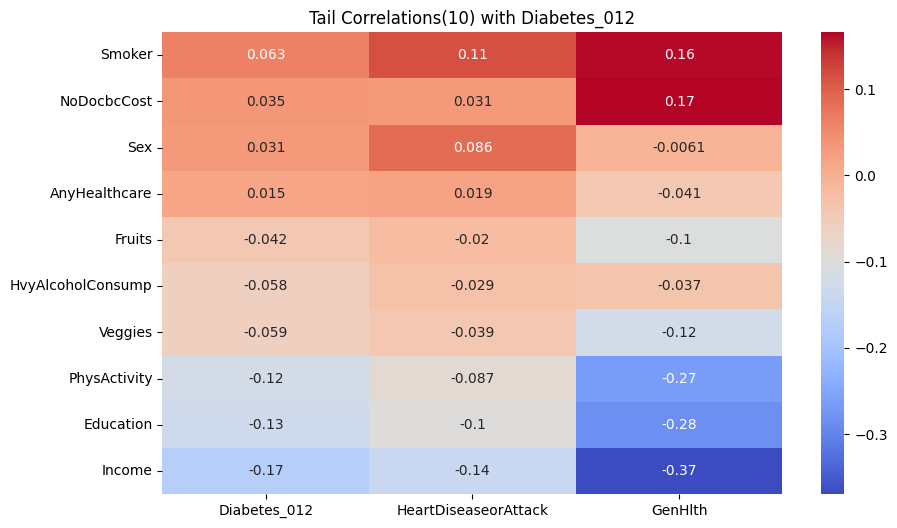

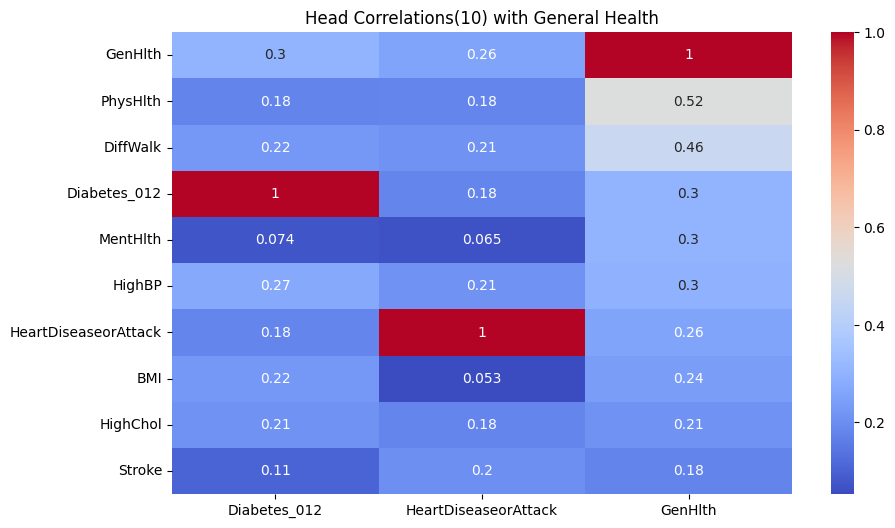

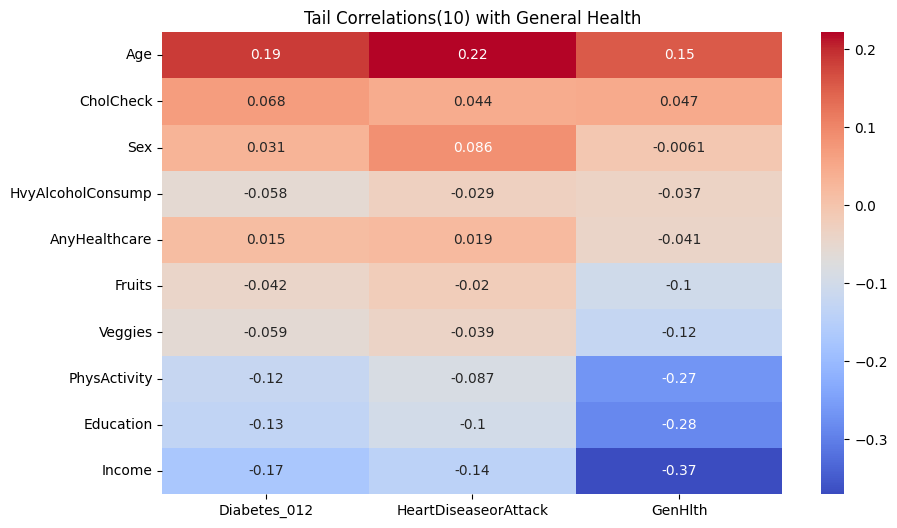

In [10]:
cols_of_interest = ["Diabetes_012", "HeartDiseaseorAttack", "GenHlth"]
diabetes_corr_subset = diabetes_corr[cols_of_interest]

sorted_by_diabetes = diabetes_corr_subset.sort_values(by="Diabetes_012", ascending=False)

plt.figure(figsize=(10,6))
sns.heatmap(sorted_by_diabetes.head(10), cmap="coolwarm", annot=True)
plt.title("Head Correlations(10) with Diabetes_012")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(sorted_by_diabetes.tail(10), cmap="coolwarm", annot=True)
plt.title("Tail Correlations(10) with Diabetes_012")
plt.show()

sorted_by_genhlth = diabetes_corr_subset.sort_values(by="GenHlth", ascending=False)

plt.figure(figsize=(10,6))
sns.heatmap(sorted_by_genhlth.head(10), cmap="coolwarm", annot=True)
plt.title("Head Correlations(10) with General Health")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(sorted_by_genhlth.tail(10), cmap="coolwarm", annot=True)
plt.title("Tail Correlations(10) with General Health")
plt.show()


I noticed with both graphs the highest correlations seem to be negative.
I noticed when sorted by diabetes_012 the highest positive correlation in the subset to all is smoking, no doctor, and sex.
The values highly correlated with themselves are counted on either.
When sorted by genHlth the highest positive correlations are age,cholCheck, and sex.
Both have sex in common being in the top 3.

## Task 7

In [ ]:
sns.pairplot(
    diabetes,
    vars=["BMI", "Age"],
    hue="Diabetes_012",
    palette=['#FF5733', '#33FF57', '#3357FF']
)
plt.suptitle("Pair Plot: BMI vs Age by Diabetes Status", y=1.02)
plt.show()

diabetes['BMI_Quantile'] = pd.qcut(diabetes['BMI'], 10, labels=False)

sns.pairplot(
    diabetes,
    vars=["BMI_Quantile", "Age"],
    hue="Diabetes_012",
    palette=['#FF5733', '#33FF57', '#3357FF']
)
plt.suptitle("Pair Plot: Age vs BMI Quantiles by Diabetes Status", y=1.02)
plt.show()
